# 실습 7: 개인 보호 장구 탐지 (PPE Detection)

## 학습 목표
- Amazon Rekognition의 `detect_protective_equipment` API로 안전장비 착용 여부를 감지합니다.
- 작업장 안전 모니터링 시나리오를 구현합니다.

## API 개요
`detect_protective_equipment`는 이미지에서 보호장구 착용 여부를 분석합니다.
- **SummarizationAttributes**:
  - `MinConfidence`: 최소 신뢰도
  - `RequiredEquipmentTypes`: 필수 장비 타입 목록
- **반환값**: `response['Persons']`
  - `BodyParts` → `Name` (`HEAD`, `FACE`, `LEFT_HAND`, `RIGHT_HAND`)
  - `EquipmentDetections` → `Type` (`FACE_COVER`, `HEAD_COVER`, `HAND_COVER`), `CoversBodyPart.Value`

### 보호장구 타입
| 타입 | 설명 |
|---|---|
| `HEAD_COVER` | 안전모, 헬멧 |
| `FACE_COVER` | 마스크, 고글 |
| `HAND_COVER` | 안전장갑 |


In [1]:
import boto3
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# ✅ [제공 코드]
rekognition = boto3.client('rekognition', region_name='ap-northeast-2')
IMAGE_DIR = './images/'
image_filename = 'lab07.jpg'
image_path = os.path.join(IMAGE_DIR, image_filename)

def load_image_bytes(path):
    with open(path, 'rb') as f:
        return f.read()

image_bytes = load_image_bytes(image_path)
print(f"이미지 경로: {image_path}")
print(f"파일 존재 여부: {os.path.exists(image_path)}")

이미지 경로: ./images/lab07.jpg
파일 존재 여부: True


## ✏️ TODO 1: detect_protective_equipment API 호출

필수 장비로 HEAD_COVER와 FACE_COVER를 요구하는 API 호출을 작성하세요.


In [7]:
# ✏️ TODO 1: API를 호출하세요
response = rekognition.detect_protective_equipment( # ← API 메서드명
    Image={'Bytes': image_bytes},  # ← 이미지 바이트
    SummarizationAttributes={
        'MinConfidence': 80,              # ← 최소 신뢰도 (80 권장)
        'RequiredEquipmentTypes': ['HEAD_COVER']
        #'RequiredEquipmentTypes': ['HEAD_COVER', 'FACE_COVER']  # ← 'HEAD_COVER', 'FACE_COVER'
    }
)

persons = response['Persons']
print(f"감지된 인원: {len(persons)}명")

감지된 인원: 2명


## ✏️ TODO 2: 인원별 보호장구 착용 상태 출력

각 인원의 신체 부위별 보호장구 착용 여부를 출력하세요.


In [8]:
# ✏️ TODO 2: 인원별 PPE 착용 현황을 출력하세요
for i, person in enumerate(persons):
    print(f"\n인원 #{i+1}")
    print("-" * 40)
    
    for body_part in person['BodyParts']:  # ← 'BodyParts'
        part_name  = body_part['Name']  # ← 'Name'
        equipments = body_part['EquipmentDetections']  # ← 'EquipmentDetections'
        
        if equipments:
            for equip in equipments:
                etype  = equip['Type']                   # ← 'Type'
                covers = equip['CoversBodyPart']['Value']  # ← 'Value'
                conf   = equip['Confidence']
                status = "✅ 착용" if covers else "❌ 미착용/불완전"
                print(f"  {part_name}: {etype} → {status} ({conf:.1f}%)")
        else:
            print(f"  {part_name}: 보호장구 없음")


인원 #1
----------------------------------------
  FACE: 보호장구 없음
  LEFT_HAND: HAND_COVER → ✅ 착용 (89.9%)
  HEAD: HEAD_COVER → ✅ 착용 (97.6%)

인원 #2
----------------------------------------
  FACE: 보호장구 없음
  LEFT_HAND: HAND_COVER → ✅ 착용 (91.7%)
  RIGHT_HAND: HAND_COVER → ✅ 착용 (52.7%)
  HEAD: HEAD_COVER → ✅ 착용 (99.6%)


## ✏️ TODO 3: Summarization 결과로 컴플라이언스 판정

Summary를 활용하여 안전 준수율을 계산하세요.


In [9]:
# ✏️ TODO 3: Summary 기반 컴플라이언스 판정
summary      = response.get('Summary', {})
with_ppe     = summary.get('PersonsWithRequiredEquipment', [])
without_ppe  = summary.get('PersonsWithoutRequiredEquipment', [])
indeterminate= summary.get('PersonsIndeterminate', [])

print("\n📊 컴플라이언스 요약:")
print("-" * 40)
print(f"  ✅ 안전 인원: {len(with_ppe)}명")
print(f"  ❌ 미착용 인원: {len(without_ppe)}명")
print(f"  ❓ 불명확 인원: {len(indeterminate)}명")

total = len(persons)
if total > 0:
    compliance_rate = len(with_ppe) / total * 100  # ← 안전 인원 / 전체 인원 * 100
    print(f"\n  안전 준수율: {compliance_rate:.1f}%")
    if compliance_rate == 100:
        print("  🟢 전원 안전 기준 충족")
    else:
        print("  🔴 일부 인원 PPE 미착용 - 주의 요망")


📊 컴플라이언스 요약:
----------------------------------------
  ✅ 안전 인원: 2명
  ❌ 미착용 인원: 0명
  ❓ 불명확 인원: 0명

  안전 준수율: 100.0%
  🟢 전원 안전 기준 충족


## ✏️ TODO 4: PPE 착용/미착용 시각화

착용자는 초록색, 미착용자는 빨간색으로 BoundingBox를 표시하세요.


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt

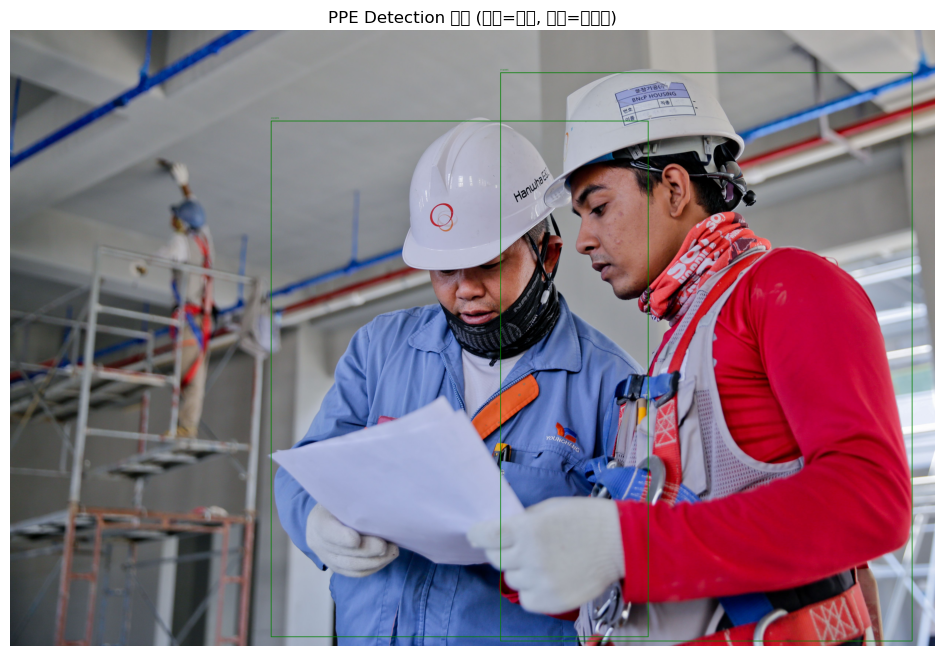

In [10]:
# ✏️ TODO 4: 안전/위험 인원을 색상으로 구분하여 표시하세요
img = Image.open(image_path)
draw = ImageDraw.Draw(img)
w, h = img.size

for i, person in enumerate(persons):
    is_safe = i in [p for p in with_ppe]  # (제공)
    color   = 'green' if is_safe else 'red'  # ← 안전:'green', 위험:'red'
    
    box    = person['BoundingBox']
    left   = box['Left']  * w
    top    = box['Top']   * h
    right  = left + box['Width']  * w
    bottom = top  + box['Height'] * h
    
    draw.rectangle([left, top, right, bottom], outline=color, width=4)
    label = "✅ SAFE" if is_safe else "❌ UNSAFE"
    draw.text((left, top - 20), f"#{i+1} {label}", fill=color)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title('PPE Detection 결과 (초록=착용, 빨강=미착용)')
plt.show()

## 💡 심화 도전
1. HAND_COVER(안전장갑)도 필수 장비로 추가하면 결과가 어떻게 달라지나요?
2. MinConfidence를 50으로 낮추면 더 많은 인원이 감지되나요?
3. **통합 프로젝트**: `detect_labels` + `detect_protective_equipment`를 결합하여
   공사 현장 이미지에서 "위험 장비(도구)" + "PPE 미착용자"를 동시에 감지하는 시스템을 만들어보세요.
